## AFCM

In [ ]:
#%pip install prince
import pandas as pd
import prince
import matplotlib.pyplot as plt
import seaborn as sns
tea = pd.read_csv("/content/tea.csv")

print(tea.head())

   Unnamed: 0      breakfast    afternoon.tea      evening      after.lunch  \
0           1      breakfast  Not.afternoon.t  not.evening  not.after.lunch   
1           2      breakfast  Not.afternoon.t  not.evening  not.after.lunch   
2           3  not.breakfast    afternoon.tea      evening  not.after.lunch   
3           4  not.breakfast  Not.afternoon.t  not.evening  not.after.lunch   
4           5      breakfast  Not.afternoon.t      evening  not.after.lunch   

       after.dinner      anytime  home      work      tearoom  ...  \
0  not.after.dinner  not.anytime  home  not.work  not.tearoom  ...   
1  not.after.dinner  not.anytime  home  not.work  not.tearoom  ...   
2      after.dinner  not.anytime  home      work  not.tearoom  ...   
3      after.dinner  not.anytime  home  not.work  not.tearoom  ...   
4  not.after.dinner      anytime  home  not.work  not.tearoom  ...   

       good.for.health      diuretic      friendliness      iron.absorption  \
0      good for health  n

In [ ]:
#%pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.3/417.3 kB 5.2 MB/s eta 0:00:00


In [ ]:
# Conversion des données en DataFrame
tea = pd.DataFrame(tea)
tea2 = tea.iloc[:, [11, 14, 15, 16, 18, 20]]
#print(tea2.head())
# Réalisation de l'ACM (MCA) sur l'ensemble du dataset
mca = prince.MCA(n_components=30, n_iter=3, copy=True, check_input=True, engine='sklearn', random_state=42)
ACM = mca.fit(tea2)
print(ACM.eigenvalues_)
#help(prince.MCA)


[2.69895960e-01 2.53182181e-01 2.25450303e-01 2.03480591e-01
 1.95511624e-01 1.82139204e-01 1.79644298e-01 1.68368480e-01
 1.63456339e-01 1.54557909e-01 1.52856329e-01 1.51328650e-01
 1.40330248e-01 1.29303203e-01 1.27336900e-01 1.21716649e-01
 9.81796311e-02 8.32615025e-02 3.46360274e-33 1.12517034e-33
 1.72486075e-34 1.07619787e-34 1.77555623e-35]


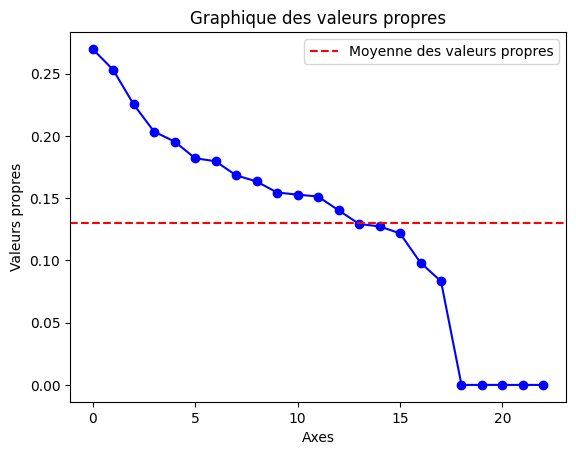

In [ ]:

# Affichage du scree plot avec la règle de Kaiser
eigenvalues = ACM.eigenvalues_
plt.plot(eigenvalues, marker='o', linestyle='-', color='blue')
plt.axhline(y=eigenvalues.mean(), color='red', linestyle='--', label='Moyenne des valeurs propres')
plt.title('Graphique des valeurs propres')
plt.xlabel('Axes')
plt.ylabel('Valeurs propres')
plt.legend()
plt.show()


In [ ]:
# Calcul de l'inertie
sumeig = sum(eigenvalues)
print("Inertie totale :", sumeig)

# Critère de Kaiser : sélection des axes dont la valeur propre est supérieure à la moyenne
mean_eigenvalue = eigenvalues.mean()
axes_selected = [i for i, eig in enumerate(eigenvalues) if eig > mean_eigenvalue]
print("Axes retenus selon le critère de Kaiser :", axes_selected)

# Contribution des variables
contributions = ACM.column_contributions_
print("Contributions des variables :", contributions)


# Extraire les coordonnées des individus et des variables
ind_coords = ACM.transform(tea2)  # Coordonnées des individus
var_coords = ACM.column_coordinates(tea2)  # Coordonnées des variables



Inertie totale : 3.0
Axes retenus selon le critère de Kaiser : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Contributions des variables :                                      0         1         2         3   \
restaurant__not.restaurant     0.008889  0.069420  0.002512  0.001469   
restaurant__restaurant         0.024867  0.194199  0.007027  0.004110   
how__lemon                     0.000564  0.007032  0.006641  0.104405   
how__milk                      0.007728  0.037819  0.132705  0.007051   
how__nothing.added             0.000002  0.020491  0.060433  0.028202   
how__other                     0.032374  0.097567  0.000597  0.148327   
sugar__not.sugar               0.046200  0.000086  0.008085  0.000089   
sugar__sugar                   0.049386  0.000092  0.008643  0.000095   
format__loose                  0.144429  0.169900  0.033365  0.007406   
format__sachet                 0.112575  0.000030  0.029884  0.009178   
format__sachet+loose           0.046667  0.061367  0.119382  

In [ ]:
# Utilisation de la table de Burt
#il faut construire le tableau de Burt de tea2 puis faire l'ACM avec


## FAMD : ACM Mixte

In [ ]:
import pandas as pd
import prince
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données "wine"
wine = pd.read_csv('/content/wine.csv')  # Utilisez le chemin correct vers votre fichier CSV
dwine = wine.iloc[:, [0, 1, 15, 21, 28, 27, 29, 30]]
print(dwine.iloc[:, 0:7].head(4))

# Réalisation de l'Analyse Factorielle des Données Mixtes (FAMD)
famd = prince.FAMD(n_components=11, n_iter=3, copy=True, check_input=True, engine='sklearn', random_state=42)
famd = famd.fit(dwine)

# Valeurs propres (eigenvalues)
eig_val = famd.eigenvalues_
print(eig_val)



  Unnamed: 0       Label  Spice  Attack.intensity  Intensity  Bitterness  \
0       2EL       Saumur  1.840             2.963      2.857       1.926   
1       1CHA      Saumur  1.739             3.036      2.893       1.926   
2       1FON  Bourgueuil  2.250             3.222      3.074       2.000   
3       1VAU      Chinon  2.167             2.704      2.462       1.963   

   Harmony  
0    3.143  
1    2.964  
2    3.143  
3    2.038  
[4.85052009 2.56161135 2.05775685 1.89880368 1.42292526 1.11167294
 1.06721964 1.0294902  1.         1.         1.        ]


## Travaux dirigés à RENDRE le 18 Janvier  à 23h59


  
Les données de Poison dans le package FactoMineR résultent d'une enquête menée auprès d'enfants du primaire ayant souffert d'une intoxication alimentaire. On leur a posé des questions sur leurs symptômes et ce qu'ils avaient mangé. Les données contiennent 55 lignes (individus) et 15 colonnes (variables).

### Partie I : AFCM sur une partie du tableau

Nous utiliserons uniquement les données concernant les enfants et certaines variables pour réaliser une analyse en correspondances multiples (ACM). Les coordonnées des individus et des variables non utilisées pourront être en supplémentaire. Les données à traiter contiennent :

- individus actifs (lignes 1:55) : individus utilisés dans l'analyse en correspondances multiples ;
- variables actives (colonnes 5:15) : variables utilisées dans l'analyse;
- variables supplémentaires ne participant pas à l'ACM. Les coordonnées de ces variables seront prédaites.

Les variables quantitatives supplémentaires (quanti. sup) : les colonnes 1 et 2 correspondant respectivement à l'âge et au temps.  
Les variables qualitatives supplémentaires (quali. sup : colonnes 3 et 4 correspondant respectivement à la colonne Maladie et Sexe). Ces variables factorielles seront utilisées pour colorier les individus en groupes.

- 1) Réalisez l'ACM de la table (disjonctive complète) des données à traiter.

- 2) D'après le tableau des valeurs propres, combien de variables factorielles devraient être étudiées dans le cadre d'une étude complète des données étudiées ?

- 3) Représentez graphiquement les données dans les plans factoriels des axes sélectionnés.

- 4)  Résumez les résultats obtenus dans ces plans factoriels.

- 5)  Réalisez l'Analyse en Correspondances en utilisant la table de Burt. Comparer les résultats avec ceux de l'ACM du tableau disjonctif

### Partie II: ACM Mixte avec toutes les variables

- 6)  Réalisez l'Analyse en Correspondances Mixte des données

### Partie III: Clustering avec les  coordonnées des axes factoriels de l'ACM Mixte

- 7)  Réalisez le clustering par CAH puis par Kmeans en utilisant la table des composantes principales de l'Analyse en Correspondances Mixte. Faites un choix raisonné du nombre de classes à retenir pour chaque méthode et décrire les groupes en fonction des variables du tableau initial.


Le travail peut être réalisé avec R ou Python!

